https://towardsdatascience.com/master-the-coco-dataset-for-semantic-image-segmentation-part-1-of-2-732712631047

In [1]:
import os
import json

import matplotlib.pyplot as plt

In [2]:
IMAGE_PATH = '/project/hnguyen2/hqvo3/Datasets/digital_pathology/TMA/QuPath_Projects/TMASegmentationR14/tiles_and_tile_masks_2048/'
JSON_PATH = '/project/hnguyen2/hqvo3/Datasets/digital_pathology/TMA/QuPath_Projects/TMASegmentationR14/tiles_and_tile_masks_2048/coco_tma_tile_rm4.json' # remove polygon list having less than or equal to 4 elements

In [3]:
with open(JSON_PATH) as f:
  json_data = json.load(f)

images = json_data['images']
annotations = json_data['annotations']

In [4]:
print('[*] type(images), len(images): ', type(images), len(images))
print('[*] type(annotations), len(annotations): ', type(annotations), len(annotations))

[*] type(images), len(images):  <class 'list'> 370648
[*] type(annotations), len(annotations):  <class 'list'> 1009948


In [5]:
print(images[0])
print(annotations[0])

{'id': 0, 'file_name': '/project/hnguyen2/hqvo3/Datasets/digital_pathology/TMA/QuPath_Projects/TMASegmentationR14/tiles_and_tile_masks_2048/C 14.30754 1ntx evg -1 - 2020-02-14 11.50.07/C 14.30754 1ntx evg -1 - 2020-02-14 11.50.07 [x=37888,y=2048,w=4096,h=4096].jpg', 'height': 2048, 'width': 2048}
{'image_id': 0, 'id': 0, 'category_id': 5, 'bbox': [1795, 1928, 252, 119], 'area': 29988, 'segmentation': [[2047, 1928, 2046, 1929, 2045, 1929, 2043, 1931, 2042, 1931, 2041, 1932, 2040, 1932, 2039, 1933, 2038, 1933, 2037, 1934, 2036, 1934, 2035, 1935, 2034, 1935, 2033, 1936, 2032, 1936, 2031, 1937, 2030, 1937, 2029, 1938, 2028, 1938, 2027, 1939, 2025, 1939, 2024, 1940, 2023, 1940, 2022, 1941, 2021, 1941, 2020, 1942, 2018, 1942, 2017, 1943, 2016, 1943, 2015, 1944, 2013, 1944, 2012, 1945, 2011, 1945, 2010, 1946, 2009, 1946, 2008, 1947, 2006, 1947, 2005, 1948, 2004, 1948, 2003, 1949, 2001, 1949, 2000, 1950, 1999, 1950, 1998, 1951, 1997, 1951, 1996, 1952, 1994, 1952, 1993, 1953, 1992, 1953, 1991, 

In [6]:
print(images[0].keys())
print(annotations[0].keys())

dict_keys(['id', 'file_name', 'height', 'width'])
dict_keys(['image_id', 'id', 'category_id', 'bbox', 'area', 'segmentation', 'iscrowd'])


In [7]:
print(images[0]['id'])
print(annotations[0]['image_id'])
print(annotations[0]['id'])
# print(annotations[1]['image_id'])
# print(annotations[1]['id'])

0
0
0


In [8]:
print(annotations[0]['bbox'])
print(annotations[0]['segmentation'][0])

[1795, 1928, 252, 119]
[2047, 1928, 2046, 1929, 2045, 1929, 2043, 1931, 2042, 1931, 2041, 1932, 2040, 1932, 2039, 1933, 2038, 1933, 2037, 1934, 2036, 1934, 2035, 1935, 2034, 1935, 2033, 1936, 2032, 1936, 2031, 1937, 2030, 1937, 2029, 1938, 2028, 1938, 2027, 1939, 2025, 1939, 2024, 1940, 2023, 1940, 2022, 1941, 2021, 1941, 2020, 1942, 2018, 1942, 2017, 1943, 2016, 1943, 2015, 1944, 2013, 1944, 2012, 1945, 2011, 1945, 2010, 1946, 2009, 1946, 2008, 1947, 2006, 1947, 2005, 1948, 2004, 1948, 2003, 1949, 2001, 1949, 2000, 1950, 1999, 1950, 1998, 1951, 1997, 1951, 1996, 1952, 1994, 1952, 1993, 1953, 1992, 1953, 1991, 1954, 1989, 1954, 1988, 1955, 1987, 1955, 1986, 1956, 1983, 1956, 1982, 1957, 1979, 1957, 1978, 1958, 1975, 1958, 1974, 1959, 1971, 1959, 1970, 1960, 1967, 1960, 1966, 1961, 1965, 1961, 1964, 1962, 1962, 1962, 1961, 1963, 1960, 1963, 1959, 1964, 1958, 1964, 1957, 1965, 1956, 1965, 1955, 1966, 1953, 1966, 1952, 1967, 1951, 1967, 1950, 1968, 1949, 1968, 1948, 1969, 1947, 1969, 1946

In [9]:
contour = annotations[0]['segmentation'][0]
l_contour = len(contour)
contour_xs = contour[0:l_contour:2]
contour_ys = contour[1:l_contour:2]
print(contour_xs)
print(contour_ys)

[2047, 2046, 2045, 2043, 2042, 2041, 2040, 2039, 2038, 2037, 2036, 2035, 2034, 2033, 2032, 2031, 2030, 2029, 2028, 2027, 2025, 2024, 2023, 2022, 2021, 2020, 2018, 2017, 2016, 2015, 2013, 2012, 2011, 2010, 2009, 2008, 2006, 2005, 2004, 2003, 2001, 2000, 1999, 1998, 1997, 1996, 1994, 1993, 1992, 1991, 1989, 1988, 1987, 1986, 1983, 1982, 1979, 1978, 1975, 1974, 1971, 1970, 1967, 1966, 1965, 1964, 1962, 1961, 1960, 1959, 1958, 1957, 1956, 1955, 1953, 1952, 1951, 1950, 1949, 1948, 1947, 1946, 1944, 1943, 1942, 1941, 1940, 1939, 1938, 1937, 1935, 1934, 1933, 1932, 1931, 1930, 1928, 1927, 1926, 1925, 1924, 1923, 1922, 1921, 1920, 1919, 1917, 1916, 1915, 1914, 1913, 1912, 1911, 1910, 1908, 1907, 1906, 1905, 1904, 1903, 1902, 1901, 1900, 1899, 1897, 1896, 1895, 1894, 1893, 1892, 1891, 1890, 1889, 1888, 1887, 1885, 1884, 1882, 1881, 1880, 1879, 1877, 1876, 1874, 1873, 1871, 1870, 1869, 1868, 1867, 1866, 1864, 1863, 1862, 1861, 1860, 1859, 1858, 1857, 1856, 1855, 1854, 1853, 1851, 1850, 1849, 184

In [10]:
print(min(contour_xs))
print(min(contour_ys))
print(max(contour_xs))
print(max(contour_ys))
print(max(contour_xs) - min(contour_xs))
print(max(contour_ys) - min(contour_ys))

1795
1928
2047
2047
252
119


# Visualization with Pycoco

In [11]:
from pycocotools.coco import COCO
import numpy as np
import skimage.io as io
import random
import os
import cv2
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

### For visualizing the outputs ###
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

In [12]:
# Dataset exploration with PyCoco
dataDir='./COCOdataset2017'
dataType='val'
annFile='{}/annotations/instances_{}.json'.format(dataDir,dataType)

# Initialize the COCO api for instance annotations
coco=COCO(JSON_PATH)

loading annotations into memory...
Done (t=194.77s)
creating index...
index created!


In [13]:
# Load the categories in a variable
catIDs = coco.getCatIds()
cats = coco.loadCats(catIDs)

print(cats)

[{'id': 0, 'name': 'Background', 'supercategory': 'Background'}, {'id': 1, 'name': 'Cortex', 'supercategory': 'Compartment'}, {'id': 2, 'name': 'Glomerulus', 'supercategory': 'Compartment'}, {'id': 3, 'name': 'Arteriole', 'supercategory': 'Compartment'}, {'id': 4, 'name': 'Artery', 'supercategory': 'Compartment'}, {'id': 5, 'name': 'Medulla', 'supercategory': 'Compartment'}, {'id': 6, 'name': 'CapsuleOther', 'supercategory': 'Compartment'}]


Number of images containing all the  classes: 1417


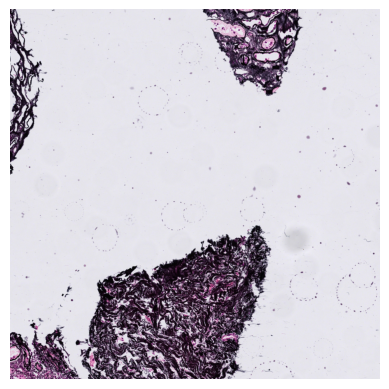

In [30]:
# Define the classes (out of the 6) which you want to see. Others will not be shown.
filterClasses = ['Cortex', 'Glomerulus', 'Artery', 'Arteriole', 'Medulla', 'CapsuleOther']
filterClasses = ['Cortex', 'Medulla', 'CapsuleOther']

# Fetch class IDs only corresponding to the filterClasses
catIds = coco.getCatIds(catNms=filterClasses) 
# Get all images containing the above Category IDs
imgIds = coco.getImgIds(catIds=catIds)
print("Number of images containing all the  classes:", len(imgIds))

# load and display a random image
img = coco.loadImgs(imgIds[np.random.randint(0,len(imgIds))])[0]
I = io.imread(img['file_name'])/255.0

plt.axis('off')
plt.imshow(I)
plt.show()

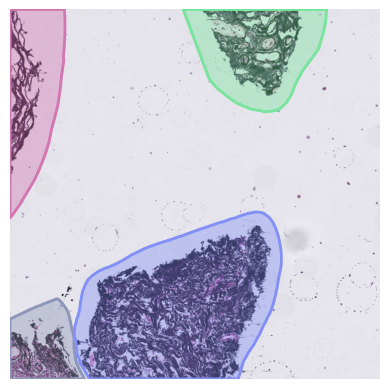

In [31]:
# Load and display instance annotations
plt.imshow(I)
plt.axis('off')
annIds = coco.getAnnIds(imgIds=img['id'], catIds=catIds, iscrowd=None)
anns = coco.loadAnns(annIds)
coco.showAnns(anns)

Number of images containing all the  classes: 81600


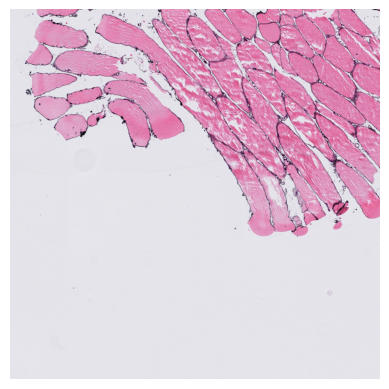

In [16]:
# Define the classes (out of the 6) which you want to see. Others will not be shown.
# filterClasses = ['Glomerulus'] # 
# filterClasses = ['Artery'] # 
# filterClasses = ['Arteriole'] # 
# filterClasses = ['Cortex'] # blue
# filterClasses = ['Medulla'] # 
filterClasses = ['CapsuleOther'] # 

# Fetch class IDs only corresponding to the filterClasses
catIds = coco.getCatIds(catNms=filterClasses) 
# Get all images containing the above Category IDs
imgIds = coco.getImgIds(catIds=catIds)
print("Number of images containing all the  classes:", len(imgIds))

# load and display a random image
img = coco.loadImgs(imgIds[np.random.randint(0,len(imgIds))])[0]
I = io.imread(img['file_name'])/255.0

plt.axis('off')
plt.imshow(I)
plt.show()

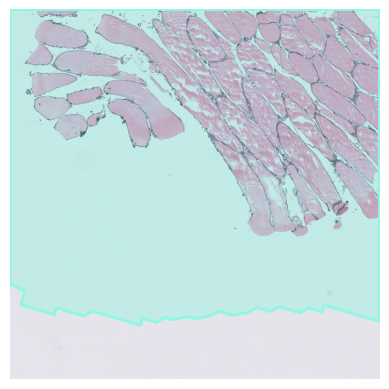

In [17]:
# Load and display instance annotations
plt.imshow(I)
plt.axis('off')
annIds = coco.getAnnIds(imgIds=img['id'], catIds=catIds, iscrowd=None)
anns = coco.loadAnns(annIds)
coco.showAnns(anns)